<div style="font-size: 0.6em; max-width: 70ch">

# Importing packages and libraries

</div>

In [1]:
import os
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from mplcursors import cursor
import seaborn as sns
import csv
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio  

# Default renderer of pio is plotly_mimetype+notebook, but jekyll fails to 
# parse plotly_mimetype.
pio.renderers.default = 'notebook_connected'
import statsmodels 

# Load the require.js library for plotly to work in jekyll, which is required 
# for interactive plots.
from IPython.display import display, HTML
js = '<script src="https://cdnjs.cloudflare.com/ajax/libs/require.js/2.3.6/' \
'require.min.js" integrity="sha512-c3Nl8+7g4LMSTdrm621y7kf9v3SDPnhxLNhc' \
'jFJbKECVnmZHTdo+IRO05sNLTH/D3vA6u1X32ehoLC7WFVdheg==" ' \
'crossorigin="anonymous"></script>'
display(HTML(js))

# Import the custom modules  
import hts.core as hts
import hts.variables as hts_var

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
# Suppress SettingWithCopyWarning
import warnings
warnings.filterwarnings('ignore', category=pd.errors.SettingWithCopyWarning)

<div style="font-size: 0.6em">

# Importing and cleaning of the primary raw data

</div>

In [2]:
# Create a dictionary that maps each folder path to a specific ID number
# The data is one level up from the notebooks.
folder_dict = {
    '1': '../data/plate1',
    '2': '../data/plate2',
    '3': '../data/plate3',
    '4': '../data/plate4',
    '5': '../data/plate5'
}

df = hts.load_plates(folder_dict)

# Number of rows and columns of the dataframe
print(f"DataFrame shape: {df.shape}")

# Display the first 5 rows of the dataframe to check if it loaded correctly
df.head(5)

DataFrame shape: (1540, 289)


,Row,Column,Timepoint,Nuclei in confirmed total cell region - Number of Objects,Nuclei in confirmed total cell region - Nucleus Area [µm²] - Mean per Well,Nuclei in confirmed total cell region - Nucleus Roundness - Mean per Well,Nuclei in confirmed total cell region - Nucleus Perimeter [µm] - Mean per Well,Nuclei in confirmed total cell region - Nucleus Width [µm] - Mean per Well,Nuclei in confirmed total cell region - Nucleus Length [µm] - Mean per Well,Nuclei in confirmed total cell region - Nucleus Ratio Width to Length - Mean per Well,Nuclei in confirmed total cell region - Nucleus HOECHST 33342 Haralick Correlation 1 px - Mean per Well,Nuclei in confirmed total cell region - Nucleus HOECHST 33342 Haralick Contrast 1 px - Mean per Well,Nuclei in confirmed total cell region - Nucleus HOECHST 33342 Haralick Sum Variance 1 px - Mean per Well,Nuclei in confirmed total cell region - Nucleus HOECHST 33342 Haralick Homogeneity 1 px - Mean per Well,Nuclei in confirmed total cell region - Nucleus HOECHST 33342 SER Spot 0 px - Mean per Well,Nuclei in confirmed total cell region - Nucleus HOECHST 33342 SER Hole 0 px - Mean per Well,Nuclei in confirmed total cell region - Nucleus HOECHST 33342 SER Edge 0 px - Mean per Well,Nuclei in confirmed total cell region - Nucleus HOECHST 33342 SER Ridge 0 px - Mean per Well,Nuclei in confirmed total cell region - Nucleus HOECHST 33342 SER Valley 0 px - Mean per Well,Nuclei in confirmed total cell region - Nucleus HOECHST 33342 SER Saddle 0 px - Mean per Well,Nuclei in confirmed total cell region - Nucleus HOECHST 33342 SER Bright 0 px - Mean per Well,Nuclei in confirmed total cell region - Nucleus HOECHST 33342 SER Dark 0 px - Mean per Well,Nuclei in confirmed total cell region - Intensity Nucleus HOECHST 33342 Mean - Mean per Well,Nuclei in confirmed total cell region - Intensity Nucleus HOECHST 33342 StdDev - Mean per Well,Nuclei in confirmed total cell region - Intensity Nucleus HOECHST 33342 Median - Mean per Well,Nuclei in confirmed total cell region - Intensity Nucleus HOECHST 33342 Sum - Mean per Well,Nuclei in confirmed total cell region - Individual cells Selected - Mean per Well,Confirmed total cell region selected - Number of Nuclei in confirmed total cell region (2)- per Object - Sum per Well,Confirmed total cell region selected - Confirmed total cell region selected Area [µm²] - Sum per Well,Confirmed total cell region selected - Number of Spots - Sum per Well,Individual cells Selected - Number of Objects,Individual cells Selected - Nucleus Area [µm²] - Mean per Well,Individual cells Selected - Nucleus Roundness - Mean per Well,Individual cells Selected - Nucleus Perimeter [µm] - Mean per Well,Individual cells Selected - Nucleus Width [µm] - Mean per Well,Individual cells Selected - Nucleus Length [µm] - Mean per Well,Individual cells Selected - Nucleus Ratio Width to Length - Mean per Well,Individual cells Selected - Nucleus HOECHST 33342 Haralick Correlation 1 px - Mean per Well,Individual cells Selected - Nucleus HOECHST 33342 Haralick Contrast 1 px - Mean per Well,Individual cells Selected - Nucleus HOECHST 33342 Haralick Sum Variance 1 px - Mean per Well,Individual cells Selected - Nucleus HOECHST 33342 Haralick Homogeneity 1 px - Mean per Well,Individual cells Selected - Nucleus HOECHST 33342 SER Spot 0 px - Mean per Well,Individual cells Selected - Nucleus HOECHST 33342 SER Hole 0 px - Mean per Well,Individual cells Selected - Nucleus HOECHST 33342 SER Edge 0 px - Mean per Well,Individual cells Selected - Nucleus HOECHST 33342 SER Ridge 0 px - Mean per Well,Individual cells Selected - Nucleus HOECHST 33342 SER Valley 0 px - Mean per Well,Individual cells Selected - Nucleus HOECHST 33342 SER Saddle 0 px - Mean per Well,Individual cells Selected - Nucleus HOECHST 33342 SER Bright 0 px - Mean per Well,Individual cells Selected - Nucleus HOECHST 33342 SER Dark 0 px - Mean per Well,Individual cells Selected - Intensity Nucleus HOECHST 33342 Mean - Mean per Well,Individual cells S

<div style="font-size: 0.6em">

# Making ID for plates and wells

</div>

In [3]:
# Map the numbering of the rows to actual alphabet as seen on the plate. 
hts.map_num_to_letter(df, col='Row', inplace=True)

# Convert the col of df called "Column" to str so that we can combine several
# strings in the next step.
df.Column = df.Column.astype(str)

# Combine the plate number and the row and column of the plate to make a 
# unique id for each well.
df.loc[:, 'Plate format'] = df[
    ['File ID', 'Row', 'Column']
].apply(
        lambda x: ''.join(x), axis=1
)


<div style="font-size: 0.6em">

# Delete the unnecessary columns and resort the columns

<div style="font-size: 1.5em">

- Some of the columns are not needed for the analysis, so they will be deleted.

</div>

</div>


In [4]:
all_nan_columns = df.columns[
    df.eq('NaN').all()
].tolist()

useless_cols = all_nan_columns + [
    "Timepoint", "Time [s]", "Compound", "Concentration", 
    "Cell Type", "Cell Count", "Unnamed: 287", 
    "Number of Analyzed Fields"
]

# Delete the columns that have no value for the analysis
df.drop(columns=useless_cols, inplace=True)

In [5]:
# Change the location of the columns to make it more readable and easier to 
# analyze. The columns are moved based on the order of importance for the 
# analysis.
df.insert(0, "Plate format", 
          df.pop("Plate format")
)

df.insert(1, "File ID", 
          df.pop("File ID")
)

df.insert(2, "Individual cells Selected - Number of Objects", 
          df.pop("Individual cells Selected - Number of Objects")
)

df.insert(
    3, "Confirmed total cell region selected - " \
    "Confirmed total cell region selected Area [µm²] - Sum per Well", 
    df.pop("Confirmed total cell region selected - " \
    "Confirmed total cell region selected Area [µm²] - Sum per Well")
)

df.insert(4, "Confirmed total cell region selected - Number of Spots - " \
    "Sum per Well", 
    df.pop("Confirmed total cell region selected - Number of Spots - " \
    "Sum per Well")
)


<div style="font-size: 0.6em">

# Removing the samples with low quality and toxic samples

<div style="font-size: 1.5em; max-width: 70ch">

- The odd number wells on the plate 5 were considered problematic because the insufficient EVs for pipetting. 
The toxic samples are the wells with cell number lower than 300.

</div>

</div>

In [6]:
# Check the number of wells that have issues with detecting nuclei
zero_nuclei = df.loc[df["Individual cells Selected - Number of Objects"] == 0]
print(f"There are {len(zero_nuclei)} wells with 0 count of nuclei") 

There are 10 wells with 0 count of nuclei


In [7]:
# Because of robot pipettingproblem with the last plate and especially the even
# columns, we eliminated those columns from our analysis.
df = df.loc[~ df['Plate format'].str.contains("5B|5D|5F|5H|5J|5L|5N")] 

In [8]:
# Remove the wells with cells including and below 300 cells. The compounds of
# these wells are considered toxic.
df = df.loc[df["Individual cells Selected - Number of Objects"] > 300]

<div style="font-size: 0.6em">

# Converting the data types 

<div style="font-size: 1.5em; max-width: 70ch">

- Make sure that the columns with float values are in the correct format. Some
of the columns are in object format, which can cause issues when performing 
numerical operations. 

</div>

</div>
 

In [9]:
df.dtypes

Plate format                                                                                                               object
File ID                                                                                                                    object
Individual cells Selected - Number of Objects                                                                               int64
Confirmed total cell region selected - Confirmed total cell region selected Area [µm²] - Sum per Well                     float64
Confirmed total cell region selected - Number of Spots - Sum per Well                                                       int64
Row                                                                                                                        object
Column                                                                                                                     object
Nuclei in confirmed total cell region - Number of Objects                                 

In [10]:
# Converting the columns that have float data but are stored as object. The 
# first 5 columns have the correct data types.
for column in df.columns[6:]:
    if df[column].dtype == 'object':
        # Attempt to convert the column to float
        df[column] = df[column].astype(float)

<div style="font-size: 0.6em">

# Calculate EV-uptake in the new analysis 

</div>

In [11]:
df["EV-uptake"] = df[
    "Confirmed total cell region selected - Number of Spots - Sum per Well"
] / df[
    "Confirmed total cell region selected - " \
    "Confirmed total cell region selected Area [µm²] - Sum per Well"
]

# Make the EV-uptake column more accessible by moving it to the left side of 
# the dataframe. 
df = df.copy() # avoid dataframe fragmentation
df.insert(6, "EV-uptake", df.pop("EV-uptake"))

C:\Users\ardal\AppData\Local\Temp\ipykernel_4672\1055919388.py:1: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



<div style="font-size: 0.6em">

# Defining control and sample groups 

</div>

In [12]:
df_Control = df[df['Plate format'].isin(hts_var.control_wells_lopac)]
df_Sample = pd.concat([df, df_Control]).drop_duplicates(keep=False)

print(f"Number of control wells: {len(df_Control)}")
print(f"Number of sample wells: {len(df_Sample)}")

Number of control wells: 161
Number of sample wells: 1081


<div style="font-size: 0.6em">

# Quality control of the plates 

<div style="font-size: 1.5em; max-width: 70ch">

- Visualize the well-to-well variation in the plates using the plate layout. 
This can help identify any potential issues with the data, such as edge effects 
or systematic errors.

</div>

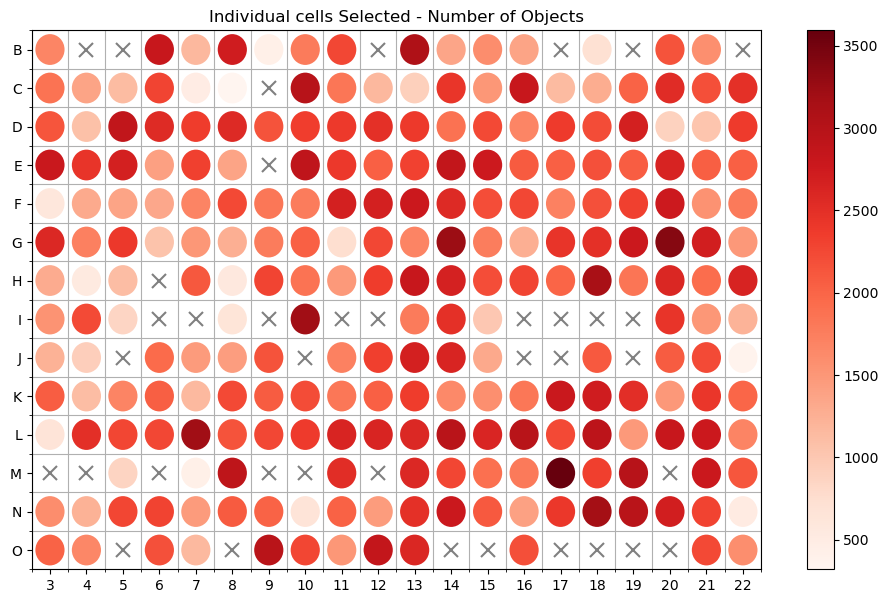

Column      3       4       5       6       7       8       9       10  \
Row                                                                      
O       2011.0  1653.0     NaN  2175.0  1152.0     NaN  2959.0  2274.0   
N       1607.0  1239.0  2275.0  2299.0  1466.0  2095.0  2013.0   655.0   
M          NaN     NaN   867.0     NaN   428.0  2909.0     NaN     NaN   
L        657.0  2506.0  2264.0  2260.0  3197.0  2150.0  2259.0  2376.0   
K       2067.0  1118.0  1699.0  2057.0  1156.0  2249.0  2073.0  2216.0   
J       1230.0   923.0     NaN  1952.0  1469.0  1441.0  2158.0     NaN   
I       1542.0  2232.0   851.0     NaN     NaN   646.0     NaN  3209.0   
H       1304.0   540.0  1117.0     NaN  2116.0   567.0  2282.0  1859.0   
G       2593.0  1739.0  2397.0  1053.0  1501.0  1255.0  1768.0  2034.0   
F        601.0  1317.0  1372.0  1338.0  1698.0  2239.0  1826.0  1771.0   
E       2793.0  2445.0  2676.0  1418.0  2315.0  1377.0     NaN  2900.0   
D       2147.0  1087.0  2890.0  2557.0

In [15]:
hts.plot_plate(df_Sample, 
               "File ID", # the col with the plate number
               1, # plate number
               "Individual cells Selected - Number of Objects")

<div style="font-size: 0.6em">

# Adding names of compounds to the dataframe  

</div>


In [13]:
df_Control = df_Control.copy()
df_Control["LOPAC_Compounds"] = "DMSO"

In [14]:
# Import the excel file showing the position of each compound on the plate
df_compounds_name = pd.read_excel(
    r"../data/LOPAC_compounds_locations.xlsx"
)

In [ ]:
# Select the columns that need for merging
compounds_name = df_compounds_name[["Plate format", "LOPAC_Compounds"]] 

In [16]:
# Check the df for compounds' names
compounds_name.head(2)

,Plate format,LOPAC_Compounds
0,3I15,Labetalol hydrochloride
1,5B3,DL-alpha-Methyl-p-tyrosine


In [17]:
# Add the name of the compounds based on the plate format
df_Sample = df_Sample.merge(
    compounds_name, 
    left_on="Plate format", 
    right_on="Plate format", 
    how="inner"
)

In [18]:
# Move the name of compounds somewhere closer to the left end of the df.
df_Control.insert(2, "LOPAC_Compounds", df_Control.pop("LOPAC_Compounds"))
df_Sample.insert(2, "LOPAC_Compounds", df_Sample.pop("LOPAC_Compounds"))

<div style="font-size: 0.6em">

# Normalization of the count of spots 

</div>

In [19]:
df_Control.head(1)

,Plate format,File ID,LOPAC_Compounds,Individual cells Selected - Number of Objects,Confirmed total cell region selected - Confirmed total cell region selected Area [µm²] - Sum per Well,Confirmed total cell region selected - Number of Spots - Sum per Well,Nuclei in confirmed total cell region - Number of Objects,EV-uptake,Nuclei in confirmed total cell region - Nucleus Area [µm²] - Mean per Well,Nuclei in confirmed total cell region - Nucleus Roundness - Mean per Well,Nuclei in confirmed total cell region - Nucleus Perimeter [µm] - Mean per Well,Nuclei in confirmed total cell region - Nucleus Width [µm] - Mean per Well,Nuclei in confirmed total cell region - Nucleus Length [µm] - Mean per Well,Nuclei in confirmed total cell region - Nucleus Ratio Width to Length - Mean per Well,Nuclei in confirmed total cell region - Nucleus HOECHST 33342 Haralick Correlation 1 px - Mean per Well,Nuclei in confirmed total cell region - Nucleus HOECHST 33342 Haralick Contrast 1 px - Mean per Well,Nuclei in confirmed total cell region - Nucleus HOECHST 33342 Haralick Sum Variance 1 px - Mean per Well,Nuclei in confirmed total cell region - Nucleus HOECHST 33342 Haralick Homogeneity 1 px - Mean per Well,Nuclei in confirmed total cell region - Nucleus HOECHST 33342 SER Spot 0 px - Mean per Well,Nuclei in confirmed total cell region - Nucleus HOECHST 33342 SER Hole 0 px - Mean per Well,Nuclei in confirmed total cell region - Nucleus HOECHST 33342 SER Edge 0 px - Mean per Well,Nuclei in confirmed total cell region - Nucleus HOECHST 33342 SER Ridge 0 px - Mean per Well,Nuclei in confirmed total cell region - Nucleus HOECHST 33342 SER Valley 0 px - Mean per Well,Nuclei in confirmed total cell region - Nucleus HOECHST 33342 SER Saddle 0 px - Mean per Well,Nuclei in confirmed total cell region - Nucleus HOECHST 33342 SER Bright 0 px - Mean per Well,Nuclei in confirmed total cell region - Nucleus HOECHST 33342 SER Dark 0 px - Mean per Well,Nuclei in confirmed total cell region - Intensity Nucleus HOECHST 33342 Mean - Mean per Well,Nuclei in confirmed total cell region - Intensity Nucleus HOECHST 33342 StdDev - Mean per Well,Nuclei in confirmed total cell region - Intensity Nucleus HOECHST 33342 Median - Mean per Well,Nuclei in confirmed total cell region - Intensity Nucleus HOECHST 33342 Sum - Mean per Well,Nuclei in confirmed total cell region - Individual cells Selected - Mean per Well,Confirmed total cell region selected - Number of Nuclei in confirmed total cell region (2)- per Object - Sum per Well,Individual cells Selected - Nucleus Area [µm²] - Mean per Well,Individual cells Selected - Nucleus Roundness - Mean per Well,Individual cells Selected - Nucleus Perimeter [µm] - Mean per Well,Individual cells Selected - Nucleus Width [µm] - Mean per Well,Individual cells Selected - Nucleus Length [µm] - Mean per Well,Individual cells Selected - Nucleus Ratio Width to Length - Mean per Well,Individual cells Selected - Nucleus HOECHST 33342 Haralick Correlation 1 px - Mean per Well,Individual cells Selected - Nucleus HOECHST 33342 Haralick Contrast 1 px - Mean per Well,Individual cells Selected - Nucleus HOECHST 33342 Haralick Sum Variance 1 px - Mean per Well,Individual cells Selected - Nucleus HOECHST 33342 Haralick Homogeneity 1 px - Mean per Well,Individual cells Selected - Nucleus HOECHST 33342 SER Spot 0 px - Mean per Well,Individual cells Selected - Nucleus HOECHST 33342 SER Hole 0 px - Mean per Well,Individual cells Selected - Nucleus HOECHST 33342 SER Edge 0 px - Mean per Well,Individual cells Selected - Nucleus HOECHST 33342 SER Ridge 0 px - Mean per Well,Individual cells Selected - Nucleus HOECHST 33342 SER Valley 0 px - Mean per Well,Individual cells Selected - Nucleus HOECHST 33342 SER Saddle 0 px - Mean per Well,Individual cells Selected - Nucleus HOECHST 33342 SER Bright 0 px - Mean per Well,Individual cells Selected - Nucleus HOECHST 33342 SER Dark 0 px - Mean per Well,Individual cells Selected - Intensity Nucleus HOECHST 33342 Mean - Mean p

In [20]:
# Normalized the plate-to-plate variation using your custom function. 
df_Control, df_Sample = hts.plate_normalizer(
    df_Control, df_Sample, "File ID", "EV-uptake"
)

In [21]:
df_Control.insert(
    8, "EV-uptake_Normalized_by_mean", 
    df_Control.pop("EV-uptake_Normalized_by_mean")
)
df_Sample.insert(
    8, "EV-uptake_Normalized_by_mean", 
    df_Sample.pop("EV-uptake_Normalized_by_mean")
)

In [22]:
df_Sample.loc[df_Sample["LOPAC_Compounds"].str.contains("Aminogua")]

,Plate format,File ID,LOPAC_Compounds,Individual cells Selected - Number of Objects,Confirmed total cell region selected - Confirmed total cell region selected Area [µm²] - Sum per Well,Confirmed total cell region selected - Number of Spots - Sum per Well,Nuclei in confirmed total cell region - Number of Objects,EV-uptake,EV-uptake_Normalized_by_mean,Nuclei in confirmed total cell region - Nucleus Area [µm²] - Mean per Well,Nuclei in confirmed total cell region - Nucleus Roundness - Mean per Well,Nuclei in confirmed total cell region - Nucleus Perimeter [µm] - Mean per Well,Nuclei in confirmed total cell region - Nucleus Width [µm] - Mean per Well,Nuclei in confirmed total cell region - Nucleus Length [µm] - Mean per Well,Nuclei in confirmed total cell region - Nucleus Ratio Width to Length - Mean per Well,Nuclei in confirmed total cell region - Nucleus HOECHST 33342 Haralick Correlation 1 px - Mean per Well,Nuclei in confirmed total cell region - Nucleus HOECHST 33342 Haralick Contrast 1 px - Mean per Well,Nuclei in confirmed total cell region - Nucleus HOECHST 33342 Haralick Sum Variance 1 px - Mean per Well,Nuclei in confirmed total cell region - Nucleus HOECHST 33342 Haralick Homogeneity 1 px - Mean per Well,Nuclei in confirmed total cell region - Nucleus HOECHST 33342 SER Spot 0 px - Mean per Well,Nuclei in confirmed total cell region - Nucleus HOECHST 33342 SER Hole 0 px - Mean per Well,Nuclei in confirmed total cell region - Nucleus HOECHST 33342 SER Edge 0 px - Mean per Well,Nuclei in confirmed total cell region - Nucleus HOECHST 33342 SER Ridge 0 px - Mean per Well,Nuclei in confirmed total cell region - Nucleus HOECHST 33342 SER Valley 0 px - Mean per Well,Nuclei in confirmed total cell region - Nucleus HOECHST 33342 SER Saddle 0 px - Mean per Well,Nuclei in confirmed total cell region - Nucleus HOECHST 33342 SER Bright 0 px - Mean per Well,Nuclei in confirmed total cell region - Nucleus HOECHST 33342 SER Dark 0 px - Mean per Well,Nuclei in confirmed total cell region - Intensity Nucleus HOECHST 33342 Mean - Mean per Well,Nuclei in confirmed total cell region - Intensity Nucleus HOECHST 33342 StdDev - Mean per Well,Nuclei in confirmed total cell region - Intensity Nucleus HOECHST 33342 Median - Mean per Well,Nuclei in confirmed total cell region - Intensity Nucleus HOECHST 33342 Sum - Mean per Well,Nuclei in confirmed total cell region - Individual cells Selected - Mean per Well,Confirmed total cell region selected - Number of Nuclei in confirmed total cell region (2)- per Object - Sum per Well,Individual cells Selected - Nucleus Area [µm²] - Mean per Well,Individual cells Selected - Nucleus Roundness - Mean per Well,Individual cells Selected - Nucleus Perimeter [µm] - Mean per Well,Individual cells Selected - Nucleus Width [µm] - Mean per Well,Individual cells Selected - Nucleus Length [µm] - Mean per Well,Individual cells Selected - Nucleus Ratio Width to Length - Mean per Well,Individual cells Selected - Nucleus HOECHST 33342 Haralick Correlation 1 px - Mean per Well,Individual cells Selected - Nucleus HOECHST 33342 Haralick Contrast 1 px - Mean per Well,Individual cells Selected - Nucleus HOECHST 33342 Haralick Sum Variance 1 px - Mean per Well,Individual cells Selected - Nucleus HOECHST 33342 Haralick Homogeneity 1 px - Mean per Well,Individual cells Selected - Nucleus HOECHST 33342 SER Spot 0 px - Mean per Well,Individual cells Selected - Nucleus HOECHST 33342 SER Hole 0 px - Mean per Well,Individual cells Selected - Nucleus HOECHST 33342 SER Edge 0 px - Mean per Well,Individual cells Selected - Nucleus HOECHST 33342 SER Ridge 0 px - Mean per Well,Individual cells Selected - Nucleus HOECHST 33342 SER Valley 0 px - Mean per Well,Individual cells Selected - Nucleus HOECHST 33342 SER Saddle 0 px - Mean per Well,Individual cells Selected - Nucleus HOECHST 33342 SER Bright 0 px - Mean per Well,Individual cells Selected - Nucleus HOECHST 33342 SER Dark 0 px - Mean per Well,Individual cells Selected - Intensity Nucleu

<div style="font-size: 0.6em">

# Categorizing compounds to inhibitors and inducers and normal 
 
</div>

In [23]:
categorized_samples = hts.Categorizer(
    normalized_column= "EV-uptake_Normalized_by_mean",
    df_untreated=df_Control,
    df_treated=df_Sample,
    func='mean',
    sd=2,
    lower_outlier='Inhibitors',
    normal='Normal',
    higher_outlier='Inducers'
)
categorized_samples.threshold_generator()
# Make a new dataframe for samples including the category of each compound
df_Sample = categorized_samples.category_generator()

The values for control mean, mean-2SD and mean+2SD, respectively:  0.038644386186536775, 0.022187453361258762, 0.05510131901181479
***Based on 2SD*** 
From the total rows number of 1,081 in treated group: 
45 or 4.16% of the rows are inhibitors 
and 
22 or 2.04% of the rows are inducers 

THE NEW DATAFRAME IS GENERATED.


In [24]:
# Move the category to a location in the beginning of the df for 
# easy visualization
df_Sample.insert(9, "Category_by_2SD", df_Sample.pop("Category_by_2SD"))

<div style="font-size: 0.6em">

# Exporting dataframes 
 
</div>

In [ ]:
export_dir = r"YOUR_EXPORT_DIRECTORY_HERE"
# Note: use csv.QUOTE_ALL to have all values in quotes. Otherwise the IDs with 
# 1E in them will become scientific notation in the csv file
df_Control.to_csv(export_dir + "/LOPAC_Controls_Bulk_2026.csv", 
    quoting=csv.QUOTE_ALL
)
df_Sample.to_csv(export_dir + "/LOPAC_Samples_Bulk_2026.csv", 
    quoting=csv.QUOTE_ALL
)